<a href="https://colab.research.google.com/github/SofiiaBobr/goit_machine_learning/blob/main/dz_topic_4_Bobrivets_Sofiia_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнє завдання   
### California Housing: покращення моделі лінійної регресії

**Студентка:** Софія Бобрівець

У роботі виконано:

1. завантаження набору даних California Housing;
2. очищення від викидів у колонках `AveRooms`, `AveBedrms`, `AveOccup`, `Population`;
3. аналіз кореляцій і видалення однієї сильно корельованої ознаки;
4. поділ даних на навчальну і тестову вибірки;
5. стандартизацію ознак;
6. побудову моделі `LinearRegression`;
7. оцінювання за метриками R², MAE та MAPE;
8. порівняння базової та оновленої моделі.

**Обраний підхід до здачі:** намагатися отримати вищий бал шляхом можливого доопрацювання роботи відповідно до фідбеку ментора.


## 1. Імпорт необхідних бібліотек

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import zscore

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_absolute_percentage_error
)

np.set_printoptions(precision=4, suppress=True)
pd.set_option("display.max_columns", None)


## 2. Завантаження набору даних California Housing

Набір містить характеристики житлових районів Каліфорнії та цільову змінну `MedHouseVal` — медіанну вартість житла.


## Примітка щодо запуску

Під час першого запуску `fetch_california_housing()` завантажує набір даних з інтернету. Тому ноутбук потрібно виконувати з активним інтернет-з’єднанням, наприклад у Google Colab або Spyder/Jupyter.

In [2]:
housing = fetch_california_housing(as_frame=True)
df = housing.frame.copy()

print("Розмір набору даних:", df.shape)
display(df.head())


Розмір набору даних: (20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## 3. Перевірка структури даних

In [3]:
df.info()
display(df.describe().T)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


,count,mean,std,min,25%,50%,75%,max
MedInc,20640.0,3.870671,1.899822,0.499900,2.563400,3.534800,4.743250,15.000100
HouseAge,20640.0,28.639486,12.585558,1.000000,18.000000,29.000000,37.000000,52.000000
AveRooms,20640.0,5.429000,2.474173,0.846154,4.440716,5.229129,6.052381,141.909091
AveBedrms,20640.0,1.096675,0.473911,0.333333,1.006079,1.048780,1.099526,34.066667
Population,20640.0,1425.476744,1132.462122,3.000000,787.000000,1166.000000,1725.000000,35682.000000
AveOccup,20640.0,3.070655,10.386050,0.692308,2.429741,2.818116,3.282261,1243.333333
Latitude,20640.0,35.631861,2.135952,32.540000,33.930000,34.260000,37.710000,41.950000
Longitude,20640.0,-119.569704,2.003532,-124.350000,-121.800000,-118.490000,-118.010000,-114.310000
MedHouseVal,20640.0,2.068558,1.153956,0.149990,1.196000,1.797000,2.647250,5.000010


## 4. Побудова базової моделі

Базова модель будується без додаткового очищення від викидів і без видалення корельованої ознаки. Вона потрібна для подальшого порівняння.


In [4]:
X_base = df.drop(columns=["MedHouseVal"])
y_base = df["MedHouseVal"]

X_train_base, X_test_base, y_train_base, y_test_base = train_test_split(
    X_base,
    y_base,
    test_size=0.2,
    random_state=42
)

scaler_base = StandardScaler()
X_train_base_scaled = scaler_base.fit_transform(X_train_base)
X_test_base_scaled = scaler_base.transform(X_test_base)

base_model = LinearRegression()
base_model.fit(X_train_base_scaled, y_train_base)

y_pred_base = base_model.predict(X_test_base_scaled)

r2_base = r2_score(y_test_base, y_pred_base)
mae_base = mean_absolute_error(y_test_base, y_pred_base)
mape_base = mean_absolute_percentage_error(y_test_base, y_pred_base)

print(f"Базова модель:")
print(f"R²   : {r2_base:.4f}")
print(f"MAE  : {mae_base:.4f}")
print(f"MAPE : {mape_base:.4f}")


Базова модель:
R²   : 0.5758
MAE  : 0.5332
MAPE : 0.3195


## 5. Очищення від викидів за допомогою `zscore()`

Аномальними вважаємо рядки, де абсолютне значення z-score хоча б в одній із зазначених колонок перевищує 3.


In [5]:
outlier_columns = [
    "AveRooms",
    "AveBedrms",
    "AveOccup",
    "Population"
]

z_scores = df[outlier_columns].apply(zscore)

outlier_mask = (np.abs(z_scores) > 3).any(axis=1)

print("Кількість рядків до очищення:", len(df))
print("Кількість виявлених аномальних рядків:", outlier_mask.sum())

df_clean = df.loc[~outlier_mask].copy()

print("Кількість рядків після очищення:", len(df_clean))
print("Видалено рядків:", len(df) - len(df_clean))


Кількість рядків до очищення: 20640
Кількість виявлених аномальних рядків: 505
Кількість рядків після очищення: 20135
Видалено рядків: 505


## 6. Матриця кореляції

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
MedInc,1.000,-0.116,0.656,-0.167,-0.020,-0.062,-0.078,-0.016,0.689
HouseAge,-0.116,1.000,-0.216,-0.126,-0.290,-0.001,0.009,-0.101,0.105
AveRooms,0.656,-0.216,1.000,0.300,-0.087,-0.043,0.120,-0.074,0.320
AveBedrms,-0.167,-0.126,0.300,1.000,-0.045,-0.081,0.068,0.013,-0.095
Population,-0.020,-0.290,-0.087,-0.045,1.000,0.178,-0.118,0.107,-0.034
AveOccup,-0.062,-0.001,-0.043,-0.081,0.178,1.000,-0.140,0.148,-0.237
Latitude,-0.078,0.009,0.120,0.068,-0.118,-0.140,1.000,-0.928,-0.144
Longitude,-0.016,-0.101,-0.074,0.013,0.107,0.148,-0.928,1.000,-0.045
MedHouseVal,0.689,0.105,0.320,-0.095,-0.034,-0.237,-0.144,-0.045,1.000


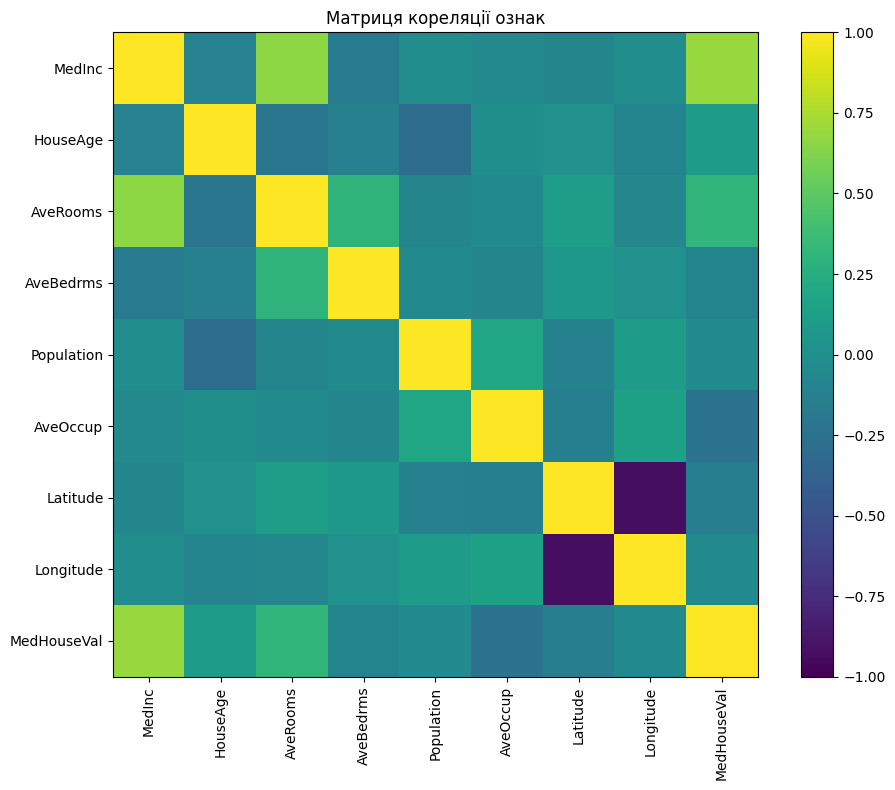

In [6]:
corr_matrix = df_clean.corr(numeric_only=True)

display(corr_matrix.round(3))

fig, ax = plt.subplots(figsize=(10, 8))
image = ax.imshow(corr_matrix, vmin=-1, vmax=1)

ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_yticks(range(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns, rotation=90)
ax.set_yticklabels(corr_matrix.columns)
ax.set_title("Матриця кореляції ознак")

fig.colorbar(image, ax=ax)
plt.tight_layout()
plt.show()


## 7. Видалення сильно корельованої ознаки

Ознаки `AveRooms` та `AveBedrms` мають високий лінійний зв'язок, оскільки обидві описують середню кількість кімнат у домогосподарстві. Для зменшення мультиколінеарності видаляємо `AveBedrms`.


In [7]:
df_clean = df_clean.drop(columns=["AveBedrms"])

print("Ознаки після видалення AveBedrms:")
print(df_clean.columns.tolist())


Ознаки після видалення AveBedrms:
['MedInc', 'HouseAge', 'AveRooms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal']


## 8. Поділ даних на навчальну і тестову вибірки

In [8]:
X = df_clean.drop(columns=["MedHouseVal"])
y = df_clean["MedHouseVal"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Розмір навчальної вибірки:", X_train.shape)
print("Розмір тестової вибірки:", X_test.shape)


Розмір навчальної вибірки: (16108, 7)
Розмір тестової вибірки: (4027, 7)


## 9. Стандартизація ознак

`StandardScaler` навчається лише на навчальній вибірці, щоб уникнути витоку інформації з test-набору.


In [9]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Середні значення перших п'яти ознак після стандартизації:")
print(np.round(X_train_scaled.mean(axis=0)[:5], 4))

print("Стандартні відхилення перших п'яти ознак:")
print(np.round(X_train_scaled.std(axis=0)[:5], 4))


Середні значення перших п'яти ознак після стандартизації:
[-0. -0. -0. -0. -0.]
Стандартні відхилення перших п'яти ознак:
[1. 1. 1. 1. 1.]


## 10. Побудова оновленої моделі

In [10]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)


## 11. Оцінювання оновленої моделі

Відповідно до прикладу в умові окремо обчислюємо R² на навчальній вибірці через `model.score()`. Додатково обчислюємо R² на тестовій вибірці, щоб оцінити здатність моделі узагальнювати нові дані.

In [11]:
r2_train_updated = model.score(X_train_scaled, y_train)
r2_test_updated = r2_score(y_test, y_pred)
mae_updated = mean_absolute_error(y_test, y_pred)
mape_updated = mean_absolute_percentage_error(y_test, y_pred)

print("Оновлена модель:")
print(f"R² train: {r2_train_updated:.4f}")
print(f"R² test : {r2_test_updated:.4f}")
print(f"MAE     : {mae_updated:.4f}")
print(f"MAPE    : {mape_updated:.4f}")


Оновлена модель:
R² train: 0.6367
R² test : 0.6462
MAE     : 0.5107
MAPE    : 0.3002


## 12. Порівняння базової та оновленої моделей

In [12]:
comparison = pd.DataFrame({
    "Metric": ["R² test", "MAE", "MAPE"],
    "Baseline": [r2_base, mae_base, mape_base],
    "Updated": [r2_test_updated, mae_updated, mape_updated]
})

comparison["Difference"] = comparison["Updated"] - comparison["Baseline"]

display(comparison)


,Metric,Baseline,Updated,Difference
0,R² test,0.575788,0.646179,0.070391
1,MAE,0.533200,0.510674,-0.022526
2,MAPE,0.319522,0.300195,-0.019327


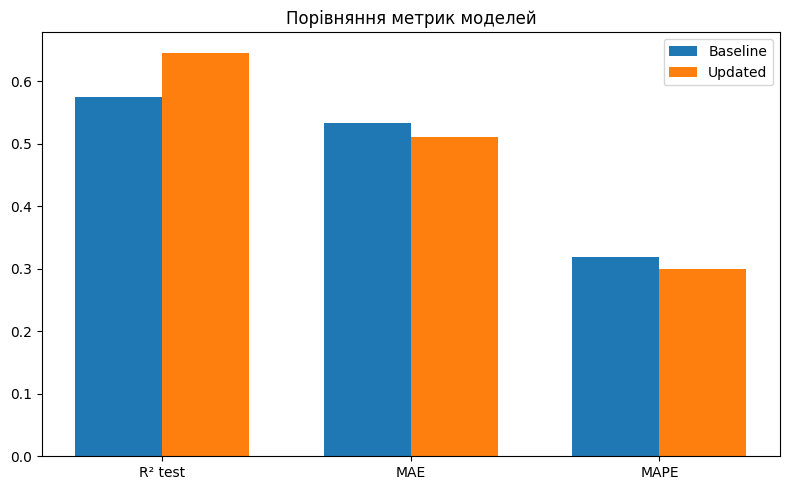

In [13]:
metrics = ["R² test", "MAE", "MAPE"]
baseline_values = [r2_base, mae_base, mape_base]
updated_values = [r2_test_updated, mae_updated, mape_updated]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width / 2, baseline_values, width, label="Baseline")
ax.bar(x + width / 2, updated_values, width, label="Updated")

ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_title("Порівняння метрик моделей")
ax.legend()
plt.tight_layout()
plt.show()


## 13. Візуальне порівняння фактичних і прогнозованих значень


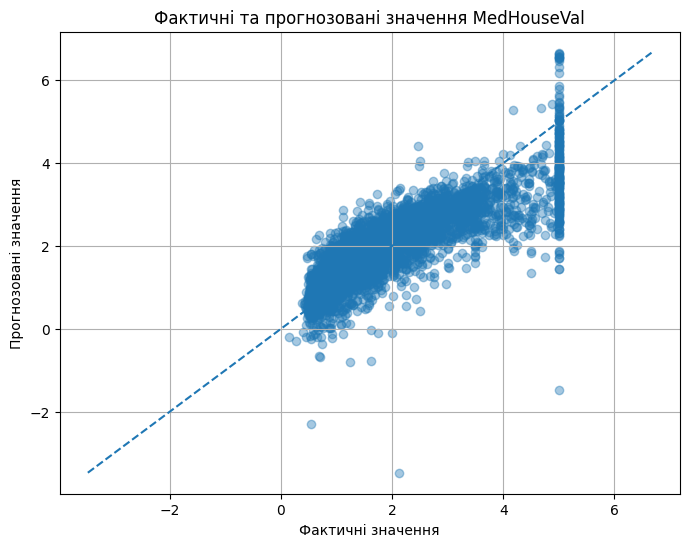

In [14]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.4)

min_value = min(y_test.min(), y_pred.min())
max_value = max(y_test.max(), y_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Фактичні значення")
plt.ylabel("Прогнозовані значення")
plt.title("Фактичні та прогнозовані значення MedHouseVal")
plt.grid()
plt.show()


# Висновки

У роботі було виконано додаткову підготовку набору California Housing перед побудовою моделі лінійної регресії.

За допомогою `zscore()` було виявлено й видалено рядки, у яких хоча б одна з ознак `AveRooms`, `AveBedrms`, `AveOccup` або `Population` мала аномальне значення. Після аналізу кореляційної матриці було видалено ознаку `AveBedrms`, яка має сильний зв’язок з `AveRooms`. Це дозволило зменшити вплив мультиколінеарності.

Далі дані було розділено на навчальну і тестову вибірки. Стандартизацію виконано правильно: `StandardScaler` навчався лише на тренувальних даних, після чого ті самі параметри були застосовані до тестових даних.

Для оцінювання моделей використано R², MAE та MAPE. Порівняння показує, як очищення від викидів і видалення корельованої ознаки вплинули на якість прогнозування. Вища оцінка R² та нижчі значення MAE і MAPE свідчать про покращення моделі.

Загалом результати підтверджують, що якість моделі машинного навчання залежить не лише від вибору алгоритму, а й від коректної послідовності попередньої обробки даних.
